# Week 3 — Turning Exercises

**Prerequisites:** Make sure you have the latest code and dependencies:
```sh
cd cobar-2026
git pull
uv sync
```

Refer to [the turning tutorial](turning.ipynb) for background on the turning controller.

## Setup

The following cells import the required libraries and define the `TurningController` class from the tutorial. Run these before starting the exercises.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from flygym.examples.locomotion import PreprogrammedSteps, CPGNetwork
from utils import LEG_NAMES, run_simulation, show_video

In [2]:
_tripod_phase_biases = np.pi * np.array(
    [
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
    ]
)
_tripod_coupling_weights = (_tripod_phase_biases > 0) * 10


class TurningController:
    """Controller that uses a CPG network to generate turning behavior.

    The controller receives a 2D descending signal to modulate the
    amplitudes and frequencies of the CPGs, producing asymmetric stepping
    for turning.

    Parameters
    ----------
    timestep : float
        Simulation timestep in seconds.
    intrinsic_freqs : np.ndarray, optional
        Intrinsic frequencies of the CPGs (Hz). Shape (6,).
    intrinsic_amps : np.ndarray, optional
        Intrinsic amplitudes of the CPGs. Shape (6,).
    phase_biases : np.ndarray, optional
        Phase biases between CPGs. Shape (6, 6).
    coupling_weights : np.ndarray, optional
        Coupling weights between CPGs. Shape (6, 6).
    convergence_coefs : np.ndarray, optional
        Rate of convergence to intrinsic amplitudes. Shape (6,).
    init_phases : np.ndarray, optional
        Initial phases. Shape (6,).
    init_magnitudes : np.ndarray, optional
        Initial magnitudes. Shape (6,).
    seed : int, optional
        Random seed for CPG network initialization.
    """

    def __init__(
        self,
        timestep,
        intrinsic_freqs=np.ones(6) * 12,
        intrinsic_amps=np.ones(6) * 1,
        phase_biases=_tripod_phase_biases,
        coupling_weights=_tripod_coupling_weights,
        convergence_coefs=np.ones(6) * 20,
        init_phases=None,
        init_magnitudes=None,
        seed=0,
    ):
        self.preprogrammed_steps = PreprogrammedSteps()
        self.intrinsic_freqs = intrinsic_freqs
        self.cpg_network = CPGNetwork(
            timestep=timestep,
            intrinsic_freqs=intrinsic_freqs,
            intrinsic_amps=intrinsic_amps,
            coupling_weights=coupling_weights,
            phase_biases=phase_biases,
            convergence_coefs=convergence_coefs,
            init_phases=init_phases,
            init_magnitudes=init_magnitudes,
            seed=seed,
        )

    def reset(self, init_phases=None, init_magnitudes=None):
        self.cpg_network.reset(init_phases=init_phases, init_magnitudes=init_magnitudes)

    def step(self, action):
        """Step the controller forward one timestep.

        Parameters
        ----------
        action : np.ndarray
            Array of shape (2,) containing the descending signal
            [delta_L, delta_R] for turning.

        Returns
        -------
        joint_angles : np.ndarray
            Flattened array of joint angles, shape (42,).
        adhesion : np.ndarray
            Adhesion on/off signal per leg, shape (6,).
        """
        # Update CPG parameters based on descending signal
        amps = np.repeat(np.abs(action[:, np.newaxis]), 3, axis=1).ravel()
        freqs = self.intrinsic_freqs.copy()
        freqs[:3] *= 1 if action[0] > 0 else -1
        freqs[3:] *= 1 if action[1] > 0 else -1
        self.cpg_network.intrinsic_amps = amps
        self.cpg_network.intrinsic_freqs = freqs

        self.cpg_network.step()

        joint_angles = np.zeros((6, 7))
        adhesion = np.zeros(6)
        for i, leg in enumerate(self.preprogrammed_steps.legs):
            joint_angles[i] = self.preprogrammed_steps.get_joint_angles(
                leg,
                self.cpg_network.curr_phases[i],
                self.cpg_network.curr_magnitudes[i],
            )
            adhesion[i] = self.preprogrammed_steps.get_adhesion_onoff(
                leg, self.cpg_network.curr_phases[i]
            )

        return joint_angles.ravel(), adhesion

In [3]:
def get_heading_angle(sim):
    """Step callback: extract the fly's heading (yaw) from its body quaternion."""
    fly_name = next(iter(sim.world.fly_lookup))
    body = sim.mj_data.body(f"{fly_name}/")
    w, x, y, z = body.xquat
    return np.arctan2(2.0 * (w * z + x * y), 1.0 - 2.0 * (y * y + z * z))


def get_position(sim):
    """Step callback: extract the fly's (x, y) position."""
    fly_name = next(iter(sim.world.fly_lookup))
    body = sim.mj_data.body(f"{fly_name}/")
    return np.array(body.xpos[:2])

## Exercise 1: Measuring turning speed

Let's quantify the fly's turning rate with a constant descending signal of $[\delta_L, \delta_R] = [1.2, 0.2]$.

**Tasks:**
1. Compute the change in heading angle over time. Use [`np.unwrap`](https://numpy.org/doc/stable/reference/generated/numpy.unwrap.html) to handle the $2\pi$ wrap-around.
2. Estimate the turning speed (rad/s) by fitting a line to the heading-angle time series using linear regression.

In [4]:
timestep = 1e-4
run_time = 2.0
num_steps = int(run_time / timestep)
warmup_steps = 1000

action = np.array([1.2, 0.2])
controller = TurningController(timestep=timestep)
joint_angles = np.zeros((num_steps, 42))
adhesion = np.zeros((num_steps, 6))
for i in range(num_steps):
    joint_angles[i], adhesion[i] = controller.step(action)

sim, heading_angles = run_simulation(
    dof_angles=joint_angles,
    adhesion_segments=[f"{leg}_tarsus5" for leg in LEG_NAMES],
    adhesion_signals=adhesion,
    step_callback=get_heading_angle,
    warmup_steps=warmup_steps,
)
heading_angles = heading_angles[warmup_steps:]
show_video(sim)

100%|██████████| 21000/21000 [00:07<00:00, 2901.91it/s]


nmf/trackcam This browser does not support the video tag.


Text(0, 0.5, 'Heading angle change (rad)')

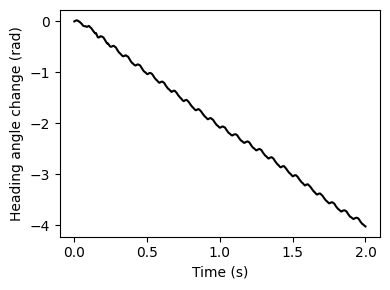

In [5]:
################################################################################
# TODO: Compute the change in heading angle over time.
# Hint: Use np.unwrap to handle the 2π wrap-around, then subtract the
# initial value.
heading_angle_unwrapped = np.unwrap(heading_angles)
heading_angle_change = heading_angle_unwrapped - heading_angle_unwrapped[0]
################################################################################

t = np.arange(num_steps) * timestep
fig, ax = plt.subplots(1, 1, figsize=(4, 3), tight_layout=True)
ax.plot(t, heading_angle_change, c="k")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Heading angle change (rad)")

Turning speed = -2.0317 rad/s


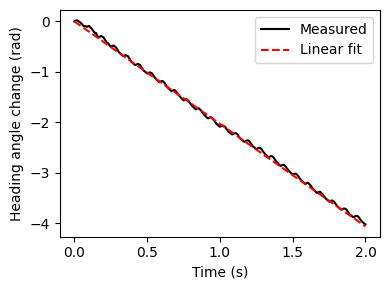

In [6]:
################################################################################
# TODO: Estimate the turning speed (rad/s) by fitting a line to the heading
# angle change. You can use statistics.linear_regression:
# https://docs.python.org/3/library/statistics.html#statistics.linear_regression
from statistics import linear_regression

turning_speed = linear_regression(t, heading_angle_change).slope
################################################################################

print(f"Turning speed = {turning_speed:.4f} rad/s")

fig, ax = plt.subplots(1, 1, figsize=(4, 3), tight_layout=True)
ax.plot(t, heading_angle_change, c="k", label="Measured")
ax.plot(t, turning_speed * t, ls="--", c="r", label="Linear fit")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Heading angle change (rad)")
ax.legend()

## Exercise 2: Drawing a figure-eight trajectory

Using the turning speed from Exercise 1, design a time-varying descending signal that makes the fly trace a figure-eight ("8") path.

**Hints:**
- How long does it take for a complete $2\pi$ turn at the measured turning speed?
- What signal makes the fly turn left vs. right?
- A figure eight consists of one full turn in one direction followed by one full turn in the other.

In [7]:
################################################################################
# TODO: Create a time-varying descending signal of shape (num_steps_total, 2)
# that traces a figure eight. Use turning_speed from Exercise 1 to determine
# how many steps are needed for a full turn with descending signals of
# [0.2, 1.2].
n_steps_full_turn = round(2 * np.pi / np.abs(turning_speed) / timestep)
turn_right = np.array([1.2, 0.2])
turn_left = np.array([0.2, 1.2])
actions = np.concatenate(
    [
        np.tile(turn_right, (n_steps_full_turn, 1)),
        np.tile(turn_left, (n_steps_full_turn, 1)),
    ]
)
num_steps_total = len(actions)
################################################################################

controller.reset()
joint_angles = np.zeros((num_steps_total, 42))
adhesion = np.zeros((num_steps_total, 6))
for i in range(num_steps_total):
    joint_angles[i], adhesion[i] = controller.step(actions[i])

sim, positions = run_simulation(
    dof_angles=joint_angles,
    adhesion_segments=[f"{leg}_tarsus5" for leg in LEG_NAMES],
    adhesion_signals=adhesion,
    step_callback=get_position,
    warmup_steps=warmup_steps,
)
positions = np.array(positions[warmup_steps:])

100%|██████████| 62852/62852 [00:21<00:00, 2882.87it/s]


In [8]:
show_video(sim)

nmf/trackcam This browser does not support the video tag.


Text(0, 0.5, 'y position (mm)')

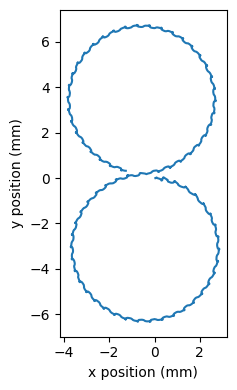

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), tight_layout=True)
ax.plot(*positions.T)
ax.set_aspect("equal")
ax.set_xlabel("x position (mm)")
ax.set_ylabel("y position (mm)")

## Exercise 3: Turning in place

Come up with a constant descending signal $[\delta_L, \delta_R]$ that makes the fly turn in place (i.e., rotate with minimal translation).

In [10]:
################################################################################
# TODO: Choose a descending signal that makes the fly rotate in place.
action_ex3 = np.array([1, -1])
################################################################################

controller_ex3 = TurningController(timestep=timestep)
run_time_ex3 = 2.0
num_steps_ex3 = int(run_time_ex3 / timestep)
joint_angles = np.zeros((num_steps_ex3, 42))
adhesion = np.zeros((num_steps_ex3, 6))
for i in range(num_steps_ex3):
    joint_angles[i], adhesion[i] = controller_ex3.step(action_ex3)

sim, _ = run_simulation(
    dof_angles=joint_angles,
    adhesion_segments=[f"{leg}_tarsus5" for leg in LEG_NAMES],
    adhesion_signals=adhesion,
    warmup_steps=warmup_steps,
)
show_video(sim)

100%|██████████| 21000/21000 [00:06<00:00, 3170.88it/s]


nmf/trackcam This browser does not support the video tag.


## Exercise 4 (bonus): Calibrated speed controller

Until now we have set the speeds in arbitrary units that scale the step distance with respect to the fly's average step size in the kinematic replay data. To be able to better control the fly it would be nicer to directly specify its forward velocity ($v_{f}$) and angular velocity ($v_\theta$).

Fit a model that roughly predicts the descending signals required to have the fly walk at a certain speed. ie. $[\delta_L, \delta_R] = f(v_f, v_r)$.

In [11]:
from itertools import product

from joblib import Parallel, delayed
from tqdm import tqdm


def run_turning_simulation(
    action,
    seed=0,
    warmup_steps=500,
    n_cycles=12,
    frequency=12,
    timestep=1e-4,
):
    """Run a short turning simulation and return the pose history.

    Returns an array of shape (num_steps, 7) where columns are
    [x, y, z, qw, qx, qy, qz].
    """

    def step_callback(sim):
        fly_name = next(iter(sim.world.fly_lookup))
        body = sim.mj_data.body(f"{fly_name}/")
        return np.concatenate((body.xpos, body.xquat))

    num_steps = int(n_cycles / frequency / timestep)
    controller = TurningController(
        timestep=timestep,
        intrinsic_freqs=np.ones(6) * frequency,
        seed=seed,
    )
    joint_angles = np.zeros((num_steps, 42))
    adhesion = np.zeros((num_steps, 6))
    for i in range(num_steps):
        joint_angles[i], adhesion[i] = controller.step(action)

    hist = run_simulation(
        dof_angles=joint_angles,
        adhesion_segments=[f"{leg}_tarsus5" for leg in LEG_NAMES],
        adhesion_signals=adhesion,
        step_callback=step_callback,
        warmup_steps=warmup_steps,
        skip_render=True,
        verbose=False,
    )[1]
    return np.array(hist)


def get_fwd_rot_vel(hists, timestep=1e-4):
    """Compute forward and rotational velocities from pose histories.

    Discards the first 2500 steps (warm-up transient), then estimates
    velocities from the remaining trajectory.

    Returns (vf, vr) — forward velocity (mm/s) and rotational velocity (rad/s).
    """
    hists = hists[..., 2500:, :]
    w, x, y, z = (hists[..., i] for i in range(3, 7))
    heading = 1 - 2 * (y * y + z * z) + 2 * (w * z + x * y) * 1j
    vf = (np.gradient(hists[..., :2] @ (1, 1j), axis=-1) / heading).real.mean(
        -1
    ) / timestep
    angles = np.unwrap(np.angle(heading), axis=-1)
    vr = (angles[..., -1] - angles[..., 0]) / ((angles.shape[-1] - 1) * timestep)
    return vf, vr

In [12]:
# Sweep over a grid of descending signals with multiple seeds
min_drive = -1.2
max_drive = 1.2
n_drives = 9
drives = np.linspace(min_drive, max_drive, n_drives)
seeds = np.arange(3)

hists = np.array(
    Parallel(n_jobs=-1)(
        delayed(run_turning_simulation)(np.array([l_drive, r_drive]), seed=seed)
        for l_drive, r_drive, seed in tqdm(list(product(drives, drives, seeds)))
    )
)

100%|██████████| 243/243 [03:25<00:00,  1.18it/s]


(np.float64(-13.06780804108704),
 np.float64(105.0667464314906),
 np.float64(-8.973062232146592),
 np.float64(97.90659881217528))

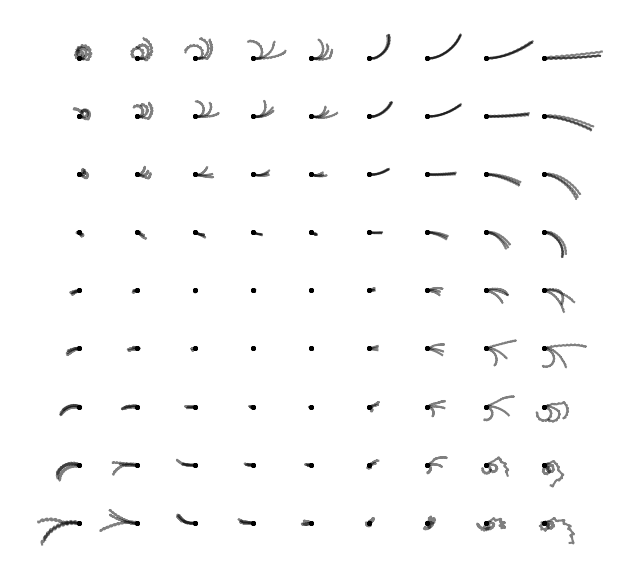

In [13]:
# Trajectory grid — each panel shows the 2D path for one (δ_L, δ_R) pair
vmax = np.abs(hists).max()
fig, ax = plt.subplots(figsize=(8, 8))
for k, xy in enumerate(hists[..., :2]):
    i, j = np.unravel_index(k, (n_drives, n_drives, len(seeds)))[:2]
    p = np.array([i, j]) * vmax
    ax.scatter(*p, c="k", s=50, lw=0, marker=".")
    ax.plot(*(xy + p).T, color="k", alpha=0.5)
ax.set_aspect("equal")
ax.axis("off")

Text(0.5, 1.0, 'Turning velocity (rad/s)')

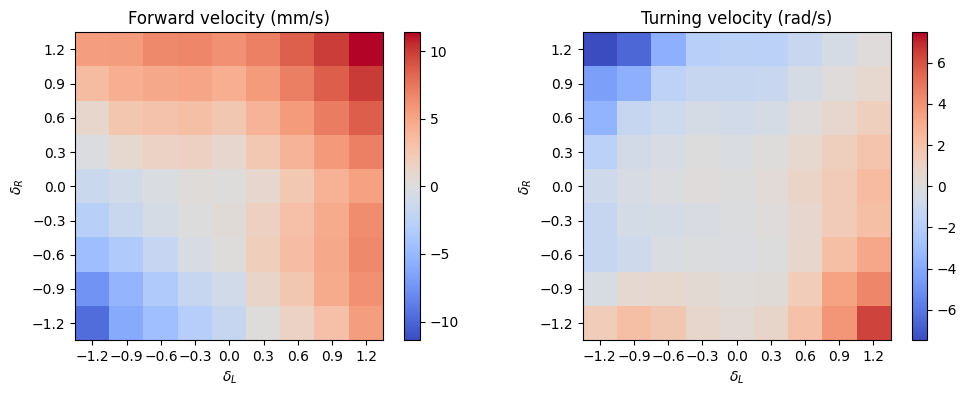

In [14]:
# Extract forward and rotational velocities, then plot heatmaps
vf, vr = get_fwd_rot_vel(hists)
im_vf = vf.reshape((n_drives, n_drives, len(seeds))).mean(axis=-1)
im_vr = vr.reshape((n_drives, n_drives, len(seeds))).mean(axis=-1)
half = (max_drive - min_drive) / (n_drives - 1) / 2
extent = (min_drive - half, max_drive + half, min_drive - half, max_drive + half)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
vmax_f = np.abs(im_vf).max()
im0 = axs[0].imshow(
    im_vf, origin="lower", extent=extent, vmax=vmax_f, vmin=-vmax_f, cmap="coolwarm"
)
vmax_r = np.abs(im_vr).max()
im1 = axs[1].imshow(
    im_vr, origin="lower", extent=extent, vmax=vmax_r, vmin=-vmax_r, cmap="coolwarm"
)

for ax in axs:
    ax.set_xticks(drives)
    ax.set_yticks(drives)
    ax.set_ylabel("$\\delta_R$")
    ax.set_xlabel("$\\delta_L$")

fig.colorbar(im0, ax=axs[0])
fig.colorbar(im1, ax=axs[1])
axs[0].set_title("Forward velocity (mm/s)")
axs[1].set_title("Turning velocity (rad/s)")

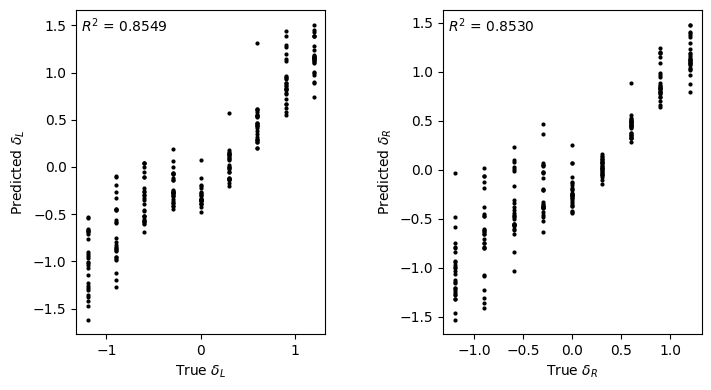

In [15]:
# Fit an inverse model: (v_f, v_θ) → (δ_L, δ_R)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression(fit_intercept=False),
)
X = np.column_stack((vf, vr))
Y = np.array(list(product(drives, drives, seeds)))[:, :2]
model.fit(X, Y)

r2 = r2_score(Y, model.predict(X), multioutput="raw_values")

fig, axs = plt.subplots(1, 2, figsize=(8, 4), tight_layout=True)
axs[0].scatter(Y[:, 0], model.predict(X)[:, 0], c="k", lw=0, marker=".")
axs[0].set_xlabel("True $\\delta_L$")
axs[0].set_ylabel("Predicted $\\delta_L$")
axs[0].text(0.02, 0.98, f"$R^2$ = {r2[0]:.4f}", transform=axs[0].transAxes, va="top")
axs[1].scatter(Y[:, 1], model.predict(X)[:, 1], c="k", lw=0, marker=".")
axs[1].set_xlabel("True $\\delta_R$")
axs[1].set_ylabel("Predicted $\\delta_R$")
axs[1].text(0.02, 0.98, f"$R^2$ = {r2[1]:.4f}", transform=axs[1].transAxes, va="top")
for ax in axs:
    ax.set_aspect(1)

In [16]:
# Test the inverse model: predict drives for target velocities, then simulate
target_vf_vr = np.array([[8, 1], [10, 0], [5, 4]])
predicted_drives = model.predict(target_vf_vr)

actual_vf_vr = np.array(
    [
        [
            get_fwd_rot_vel(run_turning_simulation(lr_drive_pred, seed=seed))
            for seed in seeds
        ]
        for lr_drive_pred in predicted_drives
    ]
)

print("Target (v_f, v_θ) → Actual mean (v_f, v_θ):")
for target, actual in zip(target_vf_vr, actual_vf_vr.mean(axis=-2)):
    print(f"  {target} → [{actual[0]:.2f}, {actual[1]:.2f}]")

Target (v_f, v_θ) → Actual mean (v_f, v_θ):
  [8 1] → [7.66, 0.93]
  [10  0] → [9.49, -0.12]
  [5 4] → [6.92, 4.17]
